In [1]:
import pandas, numpy

In [2]:
import scipy, scipy.stats

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [4]:
df = pandas.read_csv('my_dataframe.tsv', sep='\t')

In [5]:
df = pandas.read_csv('my_dataframe.tsv', sep='\t')
conditions = list(set(df['Group']))
conditions.sort()
conditions = [conditions[index] for index in [2, 1, 3, 0]]
print(conditions)

['Control', 'Catecholamine Control', 'T4 - 100 nM', 'Cat:T4 - 100 nM']


In [6]:
boxplot_values = []
for condition in conditions:
    print(condition)
    sub = df[df['Group'] == condition]
    print(sub)
    wells = list(set(sub['Well']))
    print(wells)
    all_medians = []
    for well in wells:
        print(well)
        values = sub[sub['Well'] == well]['OCR']
        print(values)
        median = values.median()
        print(median)
        all_medians.append(median)
    # about to plot
    print(all_medians)
    boxplot_values.append(all_medians)
boxplot_values

Control
    Measurement Well    Group        Time       OCR      ECAR       PER
1            29  B02  Control  182.438345  1.048234  0.422106  5.417193
3            29  C02  Control  182.438345  1.115422  0.442359  5.418902
6            29  D02  Control  182.438345  1.069696  0.402219  5.107702
10           29  E02  Control  182.438345  1.026744  0.408293  5.193427
14           29  F02  Control  182.438345  1.195843  0.413142  5.364899
17           29  G02  Control  182.438345  1.120864  0.442094  5.659219
19           30  B02  Control  188.912889  1.095270  0.409207  5.286130
21           30  C02  Control  188.912889  1.128000  0.458600  5.524206
24           30  D02  Control  188.912889  1.070346  0.404885  5.103751
28           30  E02  Control  188.912889  1.028937  0.424912  5.301122
32           30  F02  Control  188.912889  1.117098  0.402347  5.250476
35           30  G02  Control  188.912889  1.134937  0.438511  5.601915
37           31  B02  Control  195.384120  1.084652  0.4

[[1.12086374650966,
  1.11542193318001,
  1.15467514106369,
  1.08465212877282,
  1.06969601978026,
  1.02893673348938],
 [1.42768762282375, 1.41831957673062, 1.34624264688281],
 [0.782778120428707,
  1.08145569360401,
  0.784163446928774,
  0.957735428745316,
  0.984559211143171],
 [1.11088917770629, 1.10359947567239, 1.0761112475275, 1.16506755661731]]

[1.12086374650966, 1.11542193318001, 1.15467514106369, 1.08465212877282, 1.06969601978026, 1.02893673348938]
[1.42768762282375, 1.41831957673062, 1.34624264688281]
[0.782778120428707, 1.08145569360401, 0.784163446928774, 0.957735428745316, 0.984559211143171]
[1.11088917770629, 1.10359947567239, 1.0761112475275, 1.16506755661731]


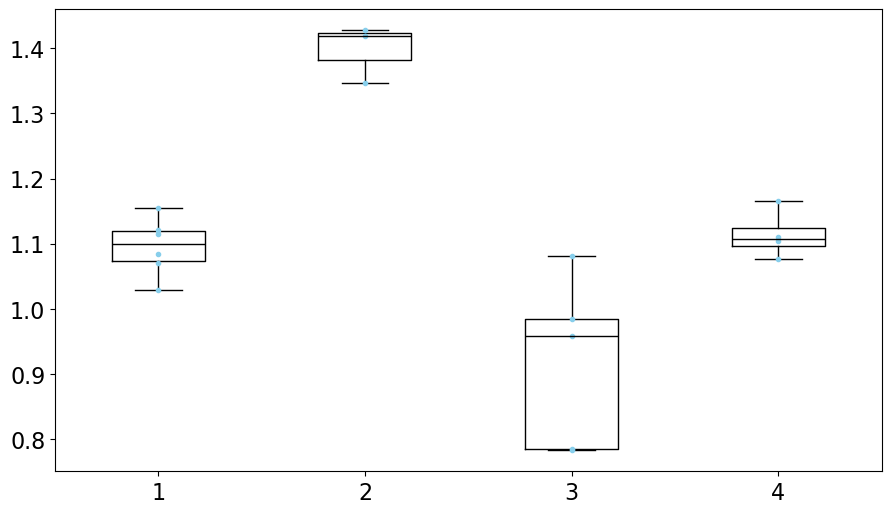

In [7]:
matplotlib.pyplot.boxplot(boxplot_values, showcaps=True, medianprops=dict(color='black'))

for i in range(len(boxplot_values)):
    dots = boxplot_values[i]
    print(dots)
    matplotlib.pyplot.plot(numpy.ones(len(dots))*(i+1), dots, '.', color='skyblue', alpha=1)
matplotlib.pyplot.show()

In [8]:
print(scipy.stats.ttest_ind(boxplot_values[2], boxplot_values[3]))
print(scipy.stats.mannwhitneyu(boxplot_values[2], boxplot_values[3]))

TtestResult(statistic=-2.85622977249109, pvalue=0.02446925343765327, df=7.0)
MannwhitneyuResult(statistic=1.0, pvalue=0.031746031746031744)


In [9]:
print(scipy.stats.ttest_ind(boxplot_values[1], boxplot_values[3]))
print(scipy.stats.mannwhitneyu(boxplot_values[1], boxplot_values[3]))

TtestResult(statistic=9.20333988352599, pvalue=0.0002541863261071592, df=5.0)
MannwhitneyuResult(statistic=12.0, pvalue=0.05714285714285714)


In [10]:
print(scipy.stats.ttest_ind(boxplot_values[0], boxplot_values[3]))
print(scipy.stats.mannwhitneyu(boxplot_values[0], boxplot_values[3]))

TtestResult(statistic=-0.6763447930724968, pvalue=0.5178941225247744, df=8.0)
MannwhitneyuResult(statistic=10.0, pvalue=0.7619047619047619)
